# 🚘 CrashLens — Vehicle Part Segmentation
## Stage 1 — Baseline Evaluation (pretrained Ultralytics Car Parts Seg, no fine-tuning)

Reference: `docs/segmentation_finetuning.md` (Section 2 and Stage 1 in Section 5), `CLAUDE.local.md` (Current TODO #1).

**Goal.** Turn "pretrained carparts-seg seems to miss CrashLens close-ups" into a measured number before any fine-tuning effort is spent (the doc's explicit gate for Stage 1). This notebook runs the pretrained model *as-is* over a Drive folder of CrashLens images split into `full/` and `cropped/` — which also operationalizes the open hypothesis in `CLAUDE.local.md`: does a wider capture framing recover most of the performance?

**Scope — Stage 1 only.**
- ✅ Load the pretrained checkpoint. No training, no gradient updates, no fine-tuning.
- ✅ Report, per subfolder: detection rate, zero-detection count, detected class distribution.
- ✅ Save annotated overlays for visual review (mask/box quality, wrong-part errors — not captured by detection rate alone).
- ✅ Log everything to Drive per the experiment convention in `docs/segmentation_finetuning.md` §7.
- 🚫 No fine-tuning (that's Stage 2). No backend or Flutter changes.

**Assumptions — confirm before running:**
1. **Drive experiment path.** The doc's example convention (§7) is `Drive/CrashLens/segmentation/experiments/...`. Per your instruction this notebook instead writes to `MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/` — a different Drive root (`carparts` vs `CrashLens`). This mirrors how the severity study actually used its own top-level root (`MyDrive/Severity_Model`) rather than a shared project folder, so it's plausibly intentional — flagging the mismatch with the doc's literal example path in case it wasn't.
2. **Input data.** `DATA_ROOT` in Section 3 is a placeholder. Set it to the actual Drive folder containing `full/` and `cropped/` subfolders of CrashLens images. Assumed flat (images directly inside each subfolder, no further nesting).
3. **Model source.** Neither `CLAUDE.md` nor `CLAUDE.local.md` record which exact pretrained checkpoint/file is "Ultralytics Car Parts Seg" for this project. `MODEL_SOURCE` in Section 3 is a placeholder — point it at your local `.pt` weights in Drive, or a Hugging Face hub id if loading via `ultralyticsplus`. Nothing is silently downloaded or substituted.
4. **Image extensions:** `.jpg`, `.jpeg`, `.png` (case-insensitive).
5. **No `weights/` folder created here** — unlike a training experiment, Stage 1 doesn't produce new weights, so the standard `weights/` folder from the doc's convention is omitted; the exact checkpoint used is recorded in `config.yaml` instead.
6. This is inference-only over existing images — no train/val/test split is created or touched, so the leak-safety rules in the doc (no duplicate images across splits, freeze test set) don't apply to this stage; they gate Stage 2 fine-tuning.

## 📁 Section 1 — Drive mount & experiment folders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

DRIVE_ROOT = '/content/drive/MyDrive/carparts/segmentation'
EXP_ID     = 'exp01_baseline_pretrained'
EXP_DIR    = os.path.join(DRIVE_ROOT, 'experiments', EXP_ID)

for sub in ['val_preds/full', 'val_preds/cropped']:
    os.makedirs(os.path.join(EXP_DIR, sub), exist_ok=True)

print('✅ Drive mounted and experiment folders ready.')
print(f'   Experiment root: {EXP_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and experiment folders ready.
   Experiment root: /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained


## 📦 Section 2 — Install Ultralytics

In [ ]:
!pip install -q ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.8/112.6 GB disk)


## ⚙️ Section 3 — Configuration (edit before running)

In [ ]:
import torch

# ── EDIT THESE ─────────────────────────────────────────────────────────────────────
DATA_ROOT    = '/content/drive/MyDrive/carparts'  # TODO: Drive folder containing full/ and cropped/
MODEL_SOURCE = '/content/drive/MyDrive/carparts/weights/best.pt'  # TODO: local .pt path, OR a hub id e.g. 'keremberke/yolov8m-car-parts-segmentation'
CONF_THRESH  = 0.25   # Ultralytics default. CLAUDE.local.md notes lowering this did NOT recover detections (domain shift, not calibration) — kept at default for the reference number
IOU_THRESH   = 0.7
IMG_SIZE     = 640
SUBFOLDERS   = ['full', 'cropped']
IMG_EXTS     = ('.jpg', '.jpeg', '.png')
# ───────────────────────────────────────────────────────────────────────────

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Config set. Device={DEVICE}')
print(f'   DATA_ROOT   : {DATA_ROOT}')
print(f'   MODEL_SOURCE: {MODEL_SOURCE}')

✅ Config set. Device=cuda
   DATA_ROOT   : /content/drive/MyDrive/carparts
   MODEL_SOURCE: /content/drive/MyDrive/carparts/weights/best.pt


## 🧠 Section 4 — Load the pretrained model (no fine-tuning)

In [ ]:
from ultralytics import YOLO

def load_pretrained_model(source):
    """Local .pt checkpoint, or a Hugging Face hub id loaded via ultralyticsplus."""
    if os.path.exists(source):
        return YOLO(source)
    if '/' in source:  # looks like a hub id, e.g. 'keremberke/yolov8m-car-parts-segmentation'
        try:
            from ultralyticsplus import YOLO as YOLOHub
        except ImportError:
            os.system('pip install -q ultralyticsplus')
            from ultralyticsplus import YOLO as YOLOHub
        return YOLOHub(source)
    raise FileNotFoundError(
        f'MODEL_SOURCE "{source}" is not a local file and does not look like a hub id. '
        'Set MODEL_SOURCE in Section 3 to the actual pretrained carparts-seg checkpoint.'
    )

model = load_pretrained_model(MODEL_SOURCE)
model.to(DEVICE)
CLASS_NAMES = model.names  # {id: name} read from the checkpoint itself — not hand-typed, so it can't drift from the real class list
print(f'✅ Model loaded: {MODEL_SOURCE}')
print(f'   Classes ({len(CLASS_NAMES)}): {list(CLASS_NAMES.values())}')

✅ Model loaded: /content/drive/MyDrive/carparts/weights/best.pt
   Classes (23): ['back_bumper', 'back_door', 'back_glass', 'back_left_door', 'back_left_light', 'back_light', 'back_right_door', 'back_right_light', 'front_bumper', 'front_door', 'front_glass', 'front_left_door', 'front_left_light', 'front_light', 'front_right_door', 'front_right_light', 'hood', 'left_mirror', 'object', 'right_mirror', 'tailgate', 'trunk', 'wheel']


## 🔍 Section 5 — Discover images per subfolder

In [ ]:
from pathlib import Path

def list_images(folder):
    p = Path(folder)
    if not p.is_dir():
        raise FileNotFoundError(f'Expected subfolder not found: {folder}')
    return sorted([f for f in p.iterdir() if f.suffix.lower() in IMG_EXTS])

image_paths = {sub: list_images(os.path.join(DATA_ROOT, sub)) for sub in SUBFOLDERS}

print('✅ Images discovered:')
for sub, paths in image_paths.items():
    print(f'   {sub:8s}: {len(paths)} images')
if sum(len(v) for v in image_paths.values()) == 0:
    raise RuntimeError('No images found — check DATA_ROOT and SUBFOLDERS in Section 3.')

✅ Images discovered:
   full    : 20 images
   cropped : 20 images


## 🖼️ Section 6 — Run inference & save annotated overlays

In [ ]:
import cv2
import pandas as pd

def run_inference(subfolder, paths):
    records = []
    preds_dir = os.path.join(EXP_DIR, 'val_preds', subfolder)
    for img_path in paths:
        result = model.predict(
            source=str(img_path), conf=CONF_THRESH, iou=IOU_THRESH,
            imgsz=IMG_SIZE, device=DEVICE, verbose=False
        )[0]

        boxes = result.boxes
        num_dets = 0 if boxes is None else len(boxes)
        classes = [] if num_dets == 0 else [CLASS_NAMES[int(c)] for c in boxes.cls]
        confs   = [] if num_dets == 0 else [float(c) for c in boxes.conf]

        annotated = result.plot()  # BGR numpy array with masks/boxes drawn
        out_path = os.path.join(preds_dir, f'{img_path.stem}_pred.jpg')
        cv2.imwrite(out_path, annotated)

        records.append({
            'subfolder': subfolder,
            'image': img_path.name,
            'num_detections': num_dets,
            'detected_classes': ';'.join(classes),
            'max_conf': max(confs) if confs else 0.0,
            'mean_conf': (sum(confs) / len(confs)) if confs else 0.0,
            'overlay_path': out_path,
        })
    return records

all_records = []
for sub, paths in image_paths.items():
    print(f'▶ Running inference on "{sub}/" ({len(paths)} images)...')
    all_records.extend(run_inference(sub, paths))

per_image_df = pd.DataFrame(all_records)
print(f'✅ Inference complete on {len(per_image_df)} images total.')
per_image_df.head()

▶ Running inference on "full/" (20 images)...
▶ Running inference on "cropped/" (20 images)...
✅ Inference complete on 40 images total.


,subfolder,image,num_detections,detected_classes,max_conf,mean_conf,overlay_path
0,full,drive__0084.JPEG,7,front_bumper;front_glass;hood;front_left_light...,0.931531,0.620884,/content/drive/MyDrive/carparts/segmentation/e...
1,full,drive__0094.JPEG,5,front_bumper;hood;front_glass;hood;front_glass,0.924481,0.649504,/content/drive/MyDrive/carparts/segmentation/e...
2,full,drive__0101.JPEG,3,front_glass;front_door;back_bumper,0.636503,0.445714,/content/drive/MyDrive/carparts/segmentation/e...
3,full,drive__0118.JPEG,4,hood;front_glass;front_bumper;front_door,0.970689,0.714422,/content/drive/MyDrive/carparts/segmentation/e...
4,full,drive__0121.JPEG,0,,0.000000,0.000000,/content/drive/MyDrive/carparts/segmentation/e...


## 📊 Section 7 — Per-subfolder metrics (detection rate, zero-detection count, class distribution)

In [ ]:
from collections import Counter

def summarize(subfolder_df, subfolder_name):
    total = len(subfolder_df)
    detected = int((subfolder_df['num_detections'] > 0).sum())
    zero_det = total - detected
    detection_rate = 100.0 * detected / total if total else 0.0

    instance_counts = Counter()      # counts every detected instance (mask), across all images
    image_level_counts = Counter()   # counts images containing >=1 instance of a class
    for classes_str in subfolder_df['detected_classes']:
        classes = [c for c in classes_str.split(';') if c]
        instance_counts.update(classes)
        image_level_counts.update(set(classes))

    return {
        'subfolder': subfolder_name,
        'total_images': total,
        'detected_images': detected,
        'zero_detection_images': zero_det,
        'detection_rate_pct': round(detection_rate, 2),
        'instance_class_distribution': dict(instance_counts),
        'image_level_class_distribution': dict(image_level_counts),
    }

summary_rows = [summarize(per_image_df[per_image_df['subfolder'] == sub], sub) for sub in SUBFOLDERS]

for row in summary_rows:
    print(f"\n📊 {row['subfolder']}/")
    print(f"   Total images          : {row['total_images']}")
    print(f"   Detection rate        : {row['detection_rate_pct']}%  ({row['detected_images']}/{row['total_images']})")
    print(f"   Zero-detection images : {row['zero_detection_images']}")
    print(f"   Class distribution (instances): {row['instance_class_distribution']}")


📊 full/
   Total images          : 20
   Detection rate        : 95.0%  (19/20)
   Zero-detection images : 1
   Class distribution (instances): {'front_bumper': 9, 'front_glass': 15, 'hood': 14, 'front_left_light': 2, 'front_right_light': 2, 'front_door': 9, 'back_bumper': 8, 'back_glass': 7, 'back_light': 7, 'back_door': 4, 'front_light': 7}

📊 cropped/
   Total images          : 20
   Detection rate        : 10.0%  (2/20)
   Zero-detection images : 18
   Class distribution (instances): {'front_bumper': 1, 'back_bumper': 1, 'trunk': 1}


In [ ]:
results_csv = os.path.join(EXP_DIR, 'results.csv')  # per-image records, per docs/segmentation_finetuning.md §7 naming
per_image_df.to_csv(results_csv, index=False)

summary_csv = os.path.join(EXP_DIR, 'results_summary.csv')
pd.DataFrame([{k: v for k, v in r.items() if not isinstance(v, dict)} for r in summary_rows]).to_csv(summary_csv, index=False)

print(f'✅ Saved per-image results  → {results_csv}')
print(f'✅ Saved subfolder summary  → {summary_csv}')

✅ Saved per-image results  → /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/results.csv
✅ Saved subfolder summary  → /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/results_summary.csv


## 📈 Section 8 — Visualize: detection rate & class distribution (full vs cropped)

The left chart is the direct test of the "does a wider framing recover performance?" hypothesis from `CLAUDE.local.md`.

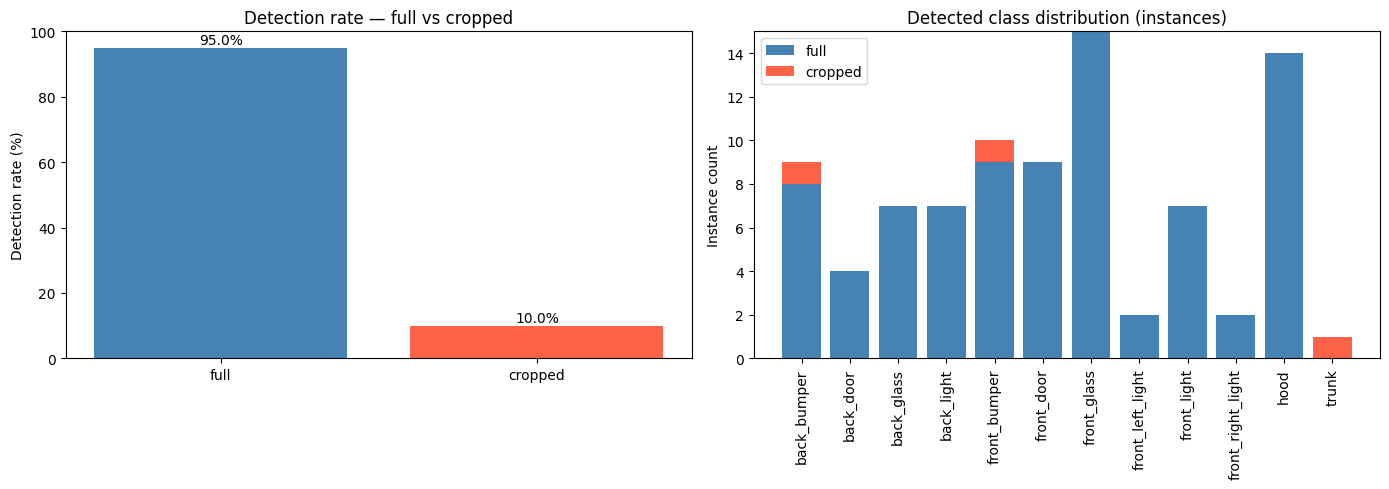

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/results.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

subs = [r['subfolder'] for r in summary_rows]
rates = [r['detection_rate_pct'] for r in summary_rows]
axes[0].bar(subs, rates, color=['steelblue', 'tomato'])
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Detection rate (%)')
axes[0].set_title('Detection rate — full vs cropped')
for i, v in enumerate(rates):
    axes[0].text(i, v + 1, f'{v}%', ha='center')

all_classes = sorted(set().union(*[r['instance_class_distribution'].keys() for r in summary_rows]))
bottom = [0] * len(all_classes)
for r, color in zip(summary_rows, ['steelblue', 'tomato']):
    counts = [r['instance_class_distribution'].get(c, 0) for c in all_classes]
    axes[1].bar(all_classes, counts, bottom=bottom, label=r['subfolder'], color=color)
    bottom = [b + c for b, c in zip(bottom, counts)]
axes[1].set_title('Detected class distribution (instances)')
axes[1].set_ylabel('Instance count')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
results_png = os.path.join(EXP_DIR, 'results.png')
plt.savefig(results_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {results_png}')

## 🗒️ Section 9 — Save `config.yaml` and `notes.md`

Per `docs/segmentation_finetuning.md` §7, `notes.md` is required for an experiment to count as finished — it's pre-filled with the measured numbers below, but the qualitative fields still need a manual pass over `val_preds/` before this experiment is "done".

In [ ]:
import yaml
from datetime import date

config = {
    'experiment_id': EXP_ID,
    'stage': 'Stage 1 — baseline (no fine-tuning)',
    'model_source': MODEL_SOURCE,
    'conf_threshold': CONF_THRESH,
    'iou_threshold': IOU_THRESH,
    'imgsz': IMG_SIZE,
    'data_root': DATA_ROOT,
    'subfolders': SUBFOLDERS,
    'num_images': {sub: len(image_paths[sub]) for sub in SUBFOLDERS},
    'date': date.today().isoformat(),
}
config_path = os.path.join(EXP_DIR, 'config.yaml')
with open(config_path, 'w') as f:
    yaml.dump(config, f, sort_keys=False)
print(f'✅ Saved → {config_path}')

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/config.yaml


In [ ]:
notes_md = f"""# {EXP_ID} — Baseline eval of pretrained carparts-seg on CrashLens images
Date: {date.today().isoformat()}
Purpose (one variable under test): Establish the Stage 1 reference detection-rate number for the stock pretrained Ultralytics Car Parts Seg model on real CrashLens images, and test whether a wider framing (full/) recovers performance relative to close-ups (cropped/), per docs/segmentation_finetuning.md Section 2/5.
Dataset version: {DATA_ROOT} (not a versioned/frozen dataset — raw CrashLens sample for baseline eval only; no train/val/test split created)
Config (lr, epochs, backbone frozen?, imgsz, augment): N/A — no training. conf={CONF_THRESH}, iou={IOU_THRESH}, imgsz={IMG_SIZE}, model_source={MODEL_SOURCE}
Training metrics: N/A — pretrained weights only, not fine-tuned
Validation metrics (independent set):
"""
for r in summary_rows:
    notes_md += f"  - {r['subfolder']}/: detection_rate={r['detection_rate_pct']}% ({r['detected_images']}/{r['total_images']}), zero_detections={r['zero_detection_images']}, instance_class_distribution={r['instance_class_distribution']}\n"

notes_md += f"""Visual predictions (paths): {os.path.join(EXP_DIR, 'val_preds')}/full/, .../cropped/
Strengths: (fill in after reviewing val_preds/ overlays)
Weaknesses: (fill in after reviewing val_preds/ overlays — note wrong-part vs no-detection vs poor mask quality separately, per docs/segmentation_finetuning.md §5 Stage 1 requirements)
Data/leakage checks done: N/A for this stage — inference only on existing images, no split created or reused
Lessons learned: (fill in — in particular: did full/ show a meaningfully higher detection rate than cropped/? If yes, this supports the close-up-framing/domain-shift hypothesis in CLAUDE.local.md rather than pointing at a need to fine-tune)
Recommended next step: (fill in — Stage 2 fine-tuning vs revisit capture framing vs both)
"""

notes_path = os.path.join(EXP_DIR, 'notes.md')
with open(notes_path, 'w', encoding='utf-8') as f:
    f.write(notes_md)
print(f'✅ Saved → {notes_path}')
print('⚠️  notes.md has placeholders — fill in Strengths/Weaknesses/Lessons/Next step after reviewing val_preds/ overlays before calling this experiment finished (per docs/segmentation_finetuning.md §7).')

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained/notes.md
⚠️  notes.md has placeholders — fill in Strengths/Weaknesses/Lessons/Next step after reviewing val_preds/ overlays before calling this experiment finished (per docs/segmentation_finetuning.md §7).


## ✅ Section 10 — Summary

In [ ]:
print('=' * 70)
print(f'STAGE 1 BASELINE — {EXP_ID}')
print('=' * 70)
for r in summary_rows:
    print(f"{r['subfolder']:8s} | detection rate: {r['detection_rate_pct']:6.2f}% | zero-detections: {r['zero_detection_images']:4d}/{r['total_images']:<4d} | classes seen: {len(r['instance_class_distribution'])}")
print('=' * 70)
print(f'Artifacts saved to: {EXP_DIR}')
print('  - results.csv (per-image)')
print('  - results_summary.csv (per-subfolder)')
print('  - results.png (detection rate + class distribution charts)')
print('  - val_preds/full/, val_preds/cropped/ (annotated overlays)')
print('  - config.yaml, notes.md')
print()
print('Next: review val_preds/ overlays for wrong-part / mask-quality issues (not just detection rate), fill in notes.md, then decide on Stage 2 per docs/segmentation_finetuning.md.')

STAGE 1 BASELINE — exp01_baseline_pretrained
full     | detection rate:  95.00% | zero-detections:    1/20   | classes seen: 11
cropped  | detection rate:  10.00% | zero-detections:   18/20   | classes seen: 3
Artifacts saved to: /content/drive/MyDrive/carparts/segmentation/experiments/exp01_baseline_pretrained
  - results.csv (per-image)
  - results_summary.csv (per-subfolder)
  - results.png (detection rate + class distribution charts)
  - val_preds/full/, val_preds/cropped/ (annotated overlays)
  - config.yaml, notes.md

Next: review val_preds/ overlays for wrong-part / mask-quality issues (not just detection rate), fill in notes.md, then decide on Stage 2 per docs/segmentation_finetuning.md.
